# CNN — Exploratory Data Analysis

## Dataset: CIFAR-100
- **Source**: `tensorflow.keras.datasets.cifar100`
- **Samples**: 60,000 images (50,000 train / 10,000 test)
- **Image size**: 32×32×3 (RGB color)
- **Classes**: 100 fine classes grouped into 20 superclasses
- **Balance**: 500 images per fine class (train), 100 per fine class (test)

## Purpose
Understand CIFAR-100's structure, class hierarchy, and visual complexity before building CNN classification pipelines in PyTorch (GPU) and TensorFlow (WSL2 GPU). Key questions: How hard is 100-class classification? Which superclasses are most confusable? What augmentation strategies will help?

## EDA Steps
1. Data quality check
2. Class distribution (fine + coarse)
3. Sample visualization by superclass
4. Pixel intensity analysis
5. Superclass difficulty analysis
6. Fine class similarity
7. Image complexity
8. Data augmentation preview

In [1]:
# Step 1: Setup

"""
Download CIFAR-100 via Keras, load both fine (100) and coarse (20) labels
CIFAR-100 is the same image format as CIFAR-10 but 10x harder
"""

import numpy as np
import matplotlib.pyplot as plt
from tensorflow.keras.datasets import cifar100

import os
EDA_DIR = '../data/raw/eda_cnn'
os.makedirs(EDA_DIR, exist_ok=True)

# Load with fine labels (100 classes)
(X_train, y_train_fine), (X_test, y_test_fine) = cifar100.load_data(label_mode='fine')

# Load coarse labels (20 superclasses) separately
(_, y_train_coarse), (_, y_test_coarse) = cifar100.load_data(label_mode='coarse')

# Flatten label arrays from (N,1) to (N,)
y_train_fine = y_train_fine.ravel()
y_test_fine = y_test_fine.ravel()
y_train_coarse = y_train_coarse.ravel()
y_test_coarse = y_test_coarse.ravel()

"""
CIFAR-100 class names from the official dataset documentation:
https://www.cs.toronto.edu/~kriz/cifar.html
Fine names are alphabetically ordered (index 0-99)
Coarse names are alphabetically ordered (index 0-19)
"""

# CIFAR-100 fine class names (official order, 0-99)
FINE_NAMES = [
    'apple', 'aquarium_fish', 'baby', 'bear', 'beaver',
    'bed', 'bee', 'beetle', 'bicycle', 'bottle',
    'bowl', 'boy', 'bridge', 'bus', 'butterfly',
    'camel', 'can', 'castle', 'caterpillar', 'cattle',
    'chair', 'chimpanzee', 'clock', 'cloud', 'cockroach',
    'couch', 'crab', 'crocodile', 'cup', 'dinosaur',
    'dolphin', 'elephant', 'flatfish', 'forest', 'fox',
    'girl', 'hamster', 'house', 'kangaroo', 'keyboard',
    'lamp', 'lawn_mower', 'leopard', 'lion', 'lizard',
    'lobster', 'man', 'maple_tree', 'motorcycle', 'mountain',
    'mouse', 'mushroom', 'oak_tree', 'orange', 'orchid',
    'otter', 'palm_tree', 'pear', 'pickup_truck', 'pine_tree',
    'plain', 'plate', 'poppy', 'porcupine', 'possum',
    'rabbit', 'raccoon', 'ray', 'road', 'rocket',
    'rose', 'sea', 'seal', 'shark', 'shrew',
    'skunk', 'skyscraper', 'snail', 'snake', 'spider',
    'squirrel', 'streetcar', 'sunflower', 'sweet_pepper', 'table',
    'tank', 'telephone', 'television', 'tiger', 'tractor',
    'train', 'trout', 'tulip', 'turtle', 'wardrobe',
    'whale', 'willow_tree', 'wolf', 'woman', 'worm'
]

# CIFAR-100 superclass names (official order, 0-19)
COARSE_NAMES = [
    'aquatic_mammals', 'fish', 'flowers', 'food_containers',
    'fruit_and_vegetables', 'household_electrical_devices',
    'household_furniture', 'insects', 'large_carnivores',
    'large_man-made_outdoor_things', 'large_natural_outdoor_scenes',
    'large_omnivores_and_herbivores', 'medium_mammals',
    'non-insect_invertebrates', 'people', 'reptiles',
    'small_mammals', 'trees', 'vehicles_1', 'vehicles_2'
]

# Superclass → fine class mapping (which fine classes belong to each superclass)
SUPERCLASS_MAP = {}
for sc in range(20):
    mask = y_train_coarse == sc
    fine_in_sc = np.unique(y_train_fine[mask])
    SUPERCLASS_MAP[COARSE_NAMES[sc]] = [FINE_NAMES[i] for i in fine_in_sc]

print("=" * 60)
print("CIFAR-100 — Exploratory Data Analysis")
print("=" * 60)
print(f"Train: {X_train.shape} | Test: {X_test.shape}")
print(f"Dtype: {X_train.dtype} | Pixel range: [{X_train.min()}, {X_train.max()}]")
print(f"Fine classes: {len(FINE_NAMES)} | Superclasses: {len(COARSE_NAMES)}")
print(f"Train labels — fine: {y_train_fine.shape}, coarse: {y_train_coarse.shape}")
print(f"\nSuperclass → Fine class mapping:")
for sc_name, fine_list in SUPERCLASS_MAP.items():
    print(f"  {sc_name}: {', '.join(fine_list)}")

c:\Users\Max\Desktop\Coding\.Projects\2026\ml-framework-comparisons\.venv\Lib\site-packages\keras\src\datasets\cifar.py:18: VisibleDeprecationWarning: dtype(): align should be passed as Python or NumPy boolean but got `align=0`. Did you mean to pass a tuple to create a subarray type? (Deprecated NumPy 2.4)
  d = cPickle.load(f, encoding="bytes")


CIFAR-100 — Exploratory Data Analysis
Train: (50000, 32, 32, 3) | Test: (10000, 32, 32, 3)
Dtype: uint8 | Pixel range: [0, 255]
Fine classes: 100 | Superclasses: 20
Train labels — fine: (50000,), coarse: (50000,)

Superclass → Fine class mapping:
  aquatic_mammals: beaver, dolphin, otter, seal, whale
  fish: aquarium_fish, flatfish, ray, shark, trout
  flowers: orchid, poppy, rose, sunflower, tulip
  food_containers: bottle, bowl, can, cup, plate
  fruit_and_vegetables: apple, mushroom, orange, pear, sweet_pepper
  household_electrical_devices: clock, keyboard, lamp, telephone, television
  household_furniture: bed, chair, couch, table, wardrobe
  insects: bee, beetle, butterfly, caterpillar, cockroach
  large_carnivores: bear, leopard, lion, tiger, wolf
  large_man-made_outdoor_things: bridge, castle, house, road, skyscraper
  large_natural_outdoor_scenes: cloud, forest, mountain, plain, sea
  large_omnivores_and_herbivores: camel, cattle, chimpanzee, elephant, kangaroo
  medium_mamma

In [2]:
# Step 2: [1/8] Data Quality

"""
Check for NaN, Inf, duplicates, and cross-set overlap
Same thorough checks as previous EDA notebooks
"""

print("=" * 60)
print("[1/8] Data Quality Check")
print("=" * 60)

# NaN and Inf checks
print(f"Train NaN:  {np.isnan(X_train.astype(float)).sum()}")
print(f"Test NaN:   {np.isnan(X_test.astype(float)).sum()}")
print(f"Train Inf:  {np.isinf(X_train.astype(float)).sum()}")
print(f"Test Inf:   {np.isinf(X_test.astype(float)).sum()}")

# Duplicate check within train set
X_train_flat = X_train.reshape(len(X_train), -1)
X_test_flat = X_test.reshape(len(X_test), -1)

n_unique_train = len(np.unique(X_train_flat, axis=0))
n_unique_test = len(np.unique(X_test_flat, axis=0))
print(f"\nTrain unique: {n_unique_train:,} / {len(X_train):,} ({len(X_train) - n_unique_train} duplicates)")
print(f"Test unique:  {n_unique_test:,} / {len(X_test):,} ({len(X_test) - n_unique_test} duplicates)")

# Cross-set overlap — are any test images in the training set?
# Hash-based check for efficiency on 60K images
train_hashes = set(map(tuple, X_train_flat))
test_hashes = set(map(tuple, X_test_flat))
overlap = len(train_hashes & test_hashes)
print(f"\nTrain-test overlap: {overlap} images")

# Label sanity check
print(f"\nFine label range:   train [{y_train_fine.min()}, {y_train_fine.max()}] | test [{y_test_fine.min()}, {y_test_fine.max()}]")
print(f"Coarse label range: train [{y_train_coarse.min()}, {y_train_coarse.max()}] | test [{y_test_coarse.min()}, {y_test_coarse.max()}]")
print(f"Fine classes in train:   {len(np.unique(y_train_fine))}")
print(f"Coarse classes in train: {len(np.unique(y_train_coarse))}")

print("\nData quality: CLEAN" if overlap == 0 else "\nWARNING: Overlap detected!")

[1/8] Data Quality Check
Train NaN:  0
Test NaN:   0
Train Inf:  0
Test Inf:   0

Train unique: 49,986 / 50,000 (14 duplicates)
Test unique:  9,998 / 10,000 (2 duplicates)

Train-test overlap: 10 images

Fine label range:   train [0, 99] | test [0, 99]
Coarse label range: train [0, 19] | test [0, 19]
Fine classes in train:   100
Coarse classes in train: 20



[2/8] Class Distribution


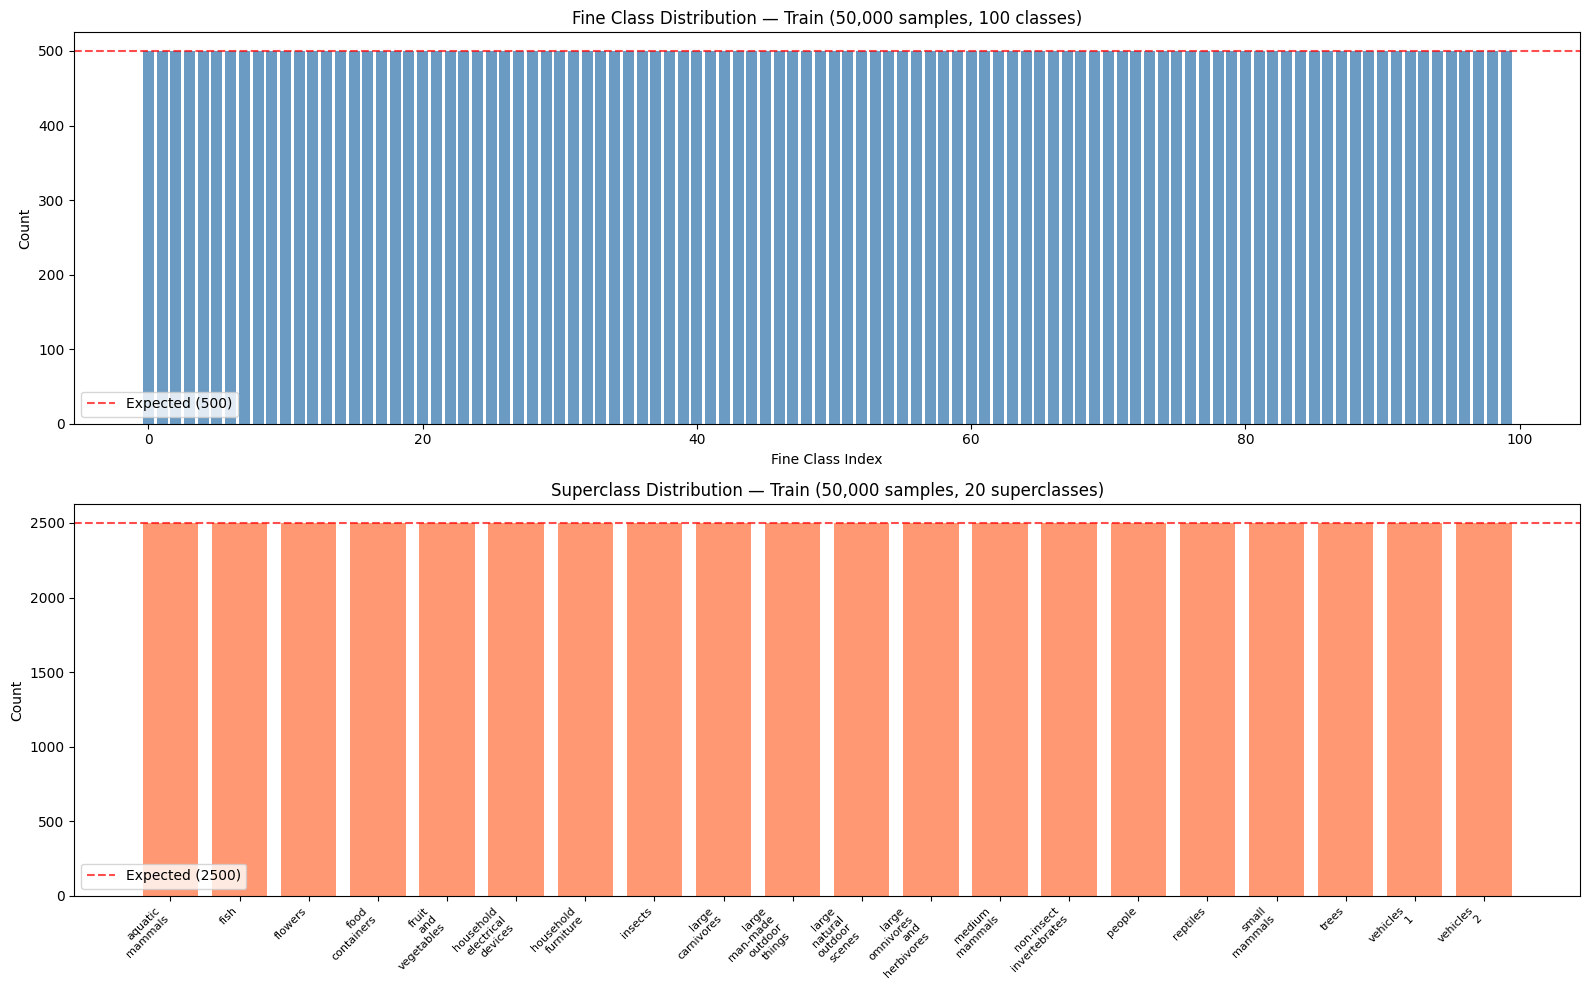


Fine classes (train): min=500, max=500, mean=500
Fine classes (test):  min=100, max=100, mean=100
Superclasses (train): min=2500, max=2500, mean=2500

Perfectly balanced: YES


In [3]:
# Step 3: [2/8] Class Distribution

"""
Verify balance across 100 fine classes and 20 superclasses
CIFAR-100 should be perfectly balanced: 500/class (train), 100/class (test)
"""

print("=" * 60)
print("[2/8] Class Distribution")
print("=" * 60)

fig, axes = plt.subplots(2, 1, figsize=(16, 10))

# Fine class distribution (100 classes)
fine_counts_train = np.bincount(y_train_fine)
fine_counts_test = np.bincount(y_test_fine)

axes[0].bar(range(100), fine_counts_train, color='steelblue', alpha=0.8)
axes[0].set_xlabel('Fine Class Index')
axes[0].set_ylabel('Count')
axes[0].set_title(f'Fine Class Distribution — Train ({len(X_train):,} samples, 100 classes)')
axes[0].axhline(y=500, color='red', linestyle='--', alpha=0.7, label='Expected (500)')
axes[0].legend()

# Superclass distribution (20 classes)
coarse_counts_train = np.bincount(y_train_coarse)
coarse_counts_test = np.bincount(y_test_coarse)

axes[1].bar(range(20), coarse_counts_train, color='coral', alpha=0.8)
axes[1].set_xticks(range(20))
axes[1].set_xticklabels([n.replace('_', '\n') for n in COARSE_NAMES],
                         rotation=45, ha='right', fontsize=8)
axes[1].set_ylabel('Count')
axes[1].set_title(f'Superclass Distribution — Train ({len(X_train):,} samples, 20 superclasses)')
axes[1].axhline(y=2500, color='red', linestyle='--', alpha=0.7, label='Expected (2500)')
axes[1].legend()

plt.tight_layout()
plt.savefig(f'{EDA_DIR}/eda_class_distribution.png', dpi=150, bbox_inches='tight')
plt.show()

# Print summary
print(f"\nFine classes (train): min={fine_counts_train.min()}, max={fine_counts_train.max()}, "
      f"mean={fine_counts_train.mean():.0f}")
print(f"Fine classes (test):  min={fine_counts_test.min()}, max={fine_counts_test.max()}, "
      f"mean={fine_counts_test.mean():.0f}")
print(f"Superclasses (train): min={coarse_counts_train.min()}, max={coarse_counts_train.max()}, "
      f"mean={coarse_counts_train.mean():.0f}")
print(f"\nPerfectly balanced: {'YES' if fine_counts_train.min() == fine_counts_train.max() else 'NO'}")

[3/8] Sample Visualization by Superclass


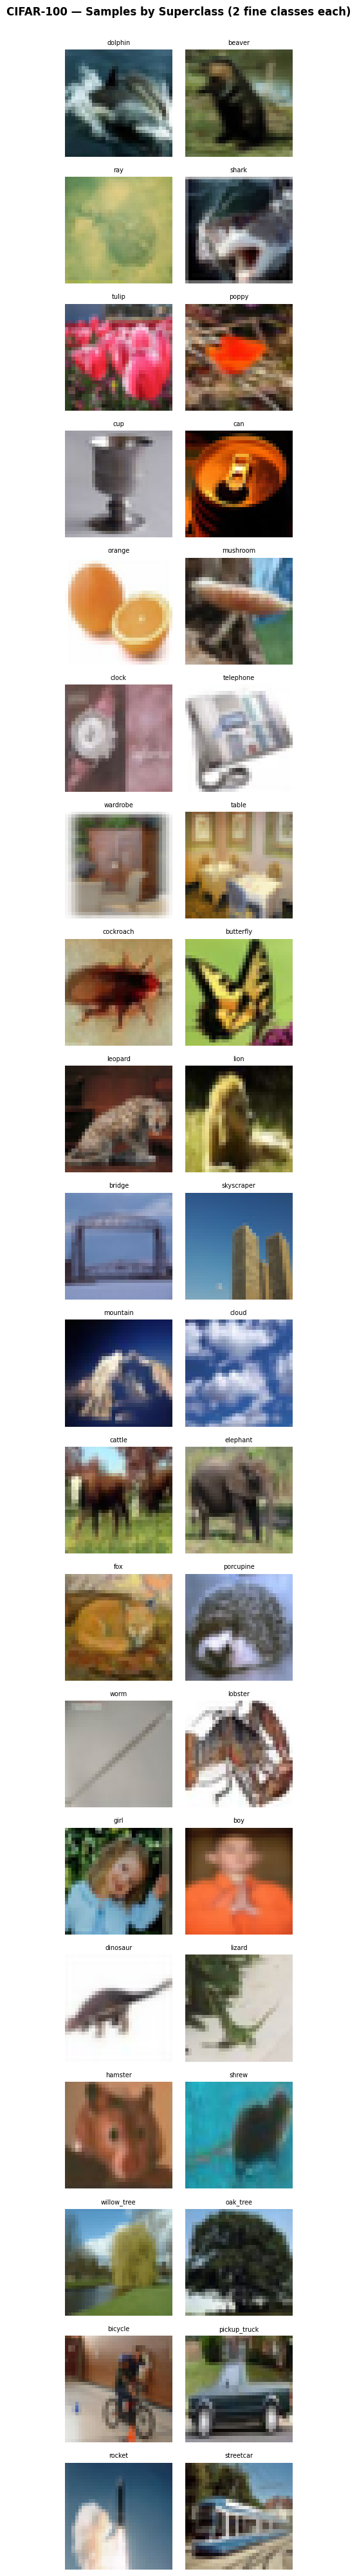

20 superclasses x 2 fine class samples displayed
Note: 32x32 resolution makes many fine classes hard to distinguish


In [4]:
# Step 4: [3/8] Sample Visualization

"""
Show 2 random images per superclass (20 superclasses × 2 = 40 images)
Groups fine classes visually — shows what the CNN needs to distinguish
"""

print("=" * 60)
print("[3/8] Sample Visualization by Superclass")
print("=" * 60)

fig, axes = plt.subplots(20, 2, figsize=(4, 40))
rng = np.random.RandomState(113)

for sc_idx in range(20):
    # Find all train images in this superclass
    mask = y_train_coarse == sc_idx
    sc_images = X_train[mask]
    sc_fine_labels = y_train_fine[mask]

    # Pick 2 random images from different fine classes if possible
    unique_fine = np.unique(sc_fine_labels)
    chosen_fine = rng.choice(unique_fine, size=2, replace=False)

    for col, fine_cls in enumerate(chosen_fine):
        fine_mask = sc_fine_labels == fine_cls
        img_idx = rng.choice(np.sum(fine_mask))
        img = sc_images[fine_mask][img_idx]

        axes[sc_idx, col].imshow(img)
        axes[sc_idx, col].axis('off')
        axes[sc_idx, col].set_title(FINE_NAMES[fine_cls], fontsize=7)

    # Add superclass label on the left
    axes[sc_idx, 0].set_ylabel(COARSE_NAMES[sc_idx].replace('_', '\n'),
                                fontsize=7, rotation=0, labelpad=60, va='center')

plt.suptitle('CIFAR-100 — Samples by Superclass (2 fine classes each)',
             fontsize=12, fontweight='bold', y=1.001)
plt.tight_layout()
plt.savefig(f'{EDA_DIR}/eda_samples_by_superclass.png', dpi=150, bbox_inches='tight')
plt.show()

print("20 superclasses x 2 fine class samples displayed")
print("Note: 32x32 resolution makes many fine classes hard to distinguish")

[4/8] Pixel Intensity Analysis


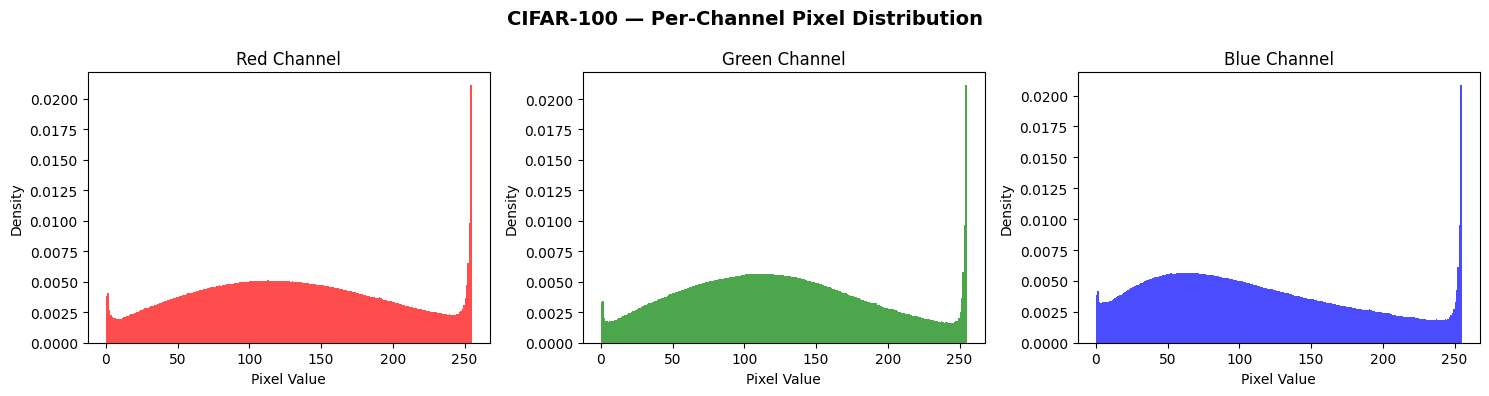


Per-channel statistics (uint8):
  Red: mean=129.30, std=68.17, min=0, max=255
  Green: mean=124.07, std=65.39, min=0, max=255
  Blue: mean=112.43, std=70.42, min=0, max=255

Per-channel statistics (normalized [0,1]):
  Red: mean=0.5071, std=0.2673
  Green: mean=0.4865, std=0.2564
  Blue: mean=0.4409, std=0.2762

Channel correlations:
  R-G: 0.8647
  G-B: 0.8857
  R-B: 0.7091


In [5]:
# Step 5: [4/8] Pixel Intensity Analysis

"""
Per-channel R/G/B histograms, mean/std per channel
Channel statistics inform normalization strategy
"""

print("=" * 60)
print("[4/8] Pixel Intensity Analysis")
print("=" * 60)

fig, axes = plt.subplots(1, 3, figsize=(15, 4))
channel_names = ['Red', 'Green', 'Blue']
channel_colors = ['red', 'green', 'blue']

for i, (name, color) in enumerate(zip(channel_names, channel_colors)):
    axes[i].hist(X_train[:, :, :, i].ravel(), bins=256, range=(0, 255),
                 color=color, alpha=0.7, density=True)
    axes[i].set_title(f'{name} Channel')
    axes[i].set_xlabel('Pixel Value')
    axes[i].set_ylabel('Density')

plt.suptitle('CIFAR-100 — Per-Channel Pixel Distribution', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig(f'{EDA_DIR}/eda_pixel_distribution.png', dpi=150, bbox_inches='tight')
plt.show()

# Per-channel statistics
print("\nPer-channel statistics (uint8):")
for i, name in enumerate(channel_names):
    ch = X_train[:, :, :, i].astype(float)
    print(f"  {name}: mean={ch.mean():.2f}, std={ch.std():.2f}, "
          f"min={ch.min():.0f}, max={ch.max():.0f}")

# Normalized [0,1] statistics (what the model will see)
X_norm = X_train.astype(np.float32) / 255.0
print("\nPer-channel statistics (normalized [0,1]):")
for i, name in enumerate(channel_names):
    ch = X_norm[:, :, :, i]
    print(f"  {name}: mean={ch.mean():.4f}, std={ch.std():.4f}")

# Channel correlation
print("\nChannel correlations:")
r = X_norm[:, :, :, 0].ravel()
g = X_norm[:, :, :, 1].ravel()
b = X_norm[:, :, :, 2].ravel()
print(f"  R-G: {np.corrcoef(r, g)[0, 1]:.4f}")
print(f"  G-B: {np.corrcoef(g, b)[0, 1]:.4f}")
print(f"  R-B: {np.corrcoef(r, b)[0, 1]:.4f}")

del X_norm  # free memory

[5/8] Superclass Difficulty Analysis


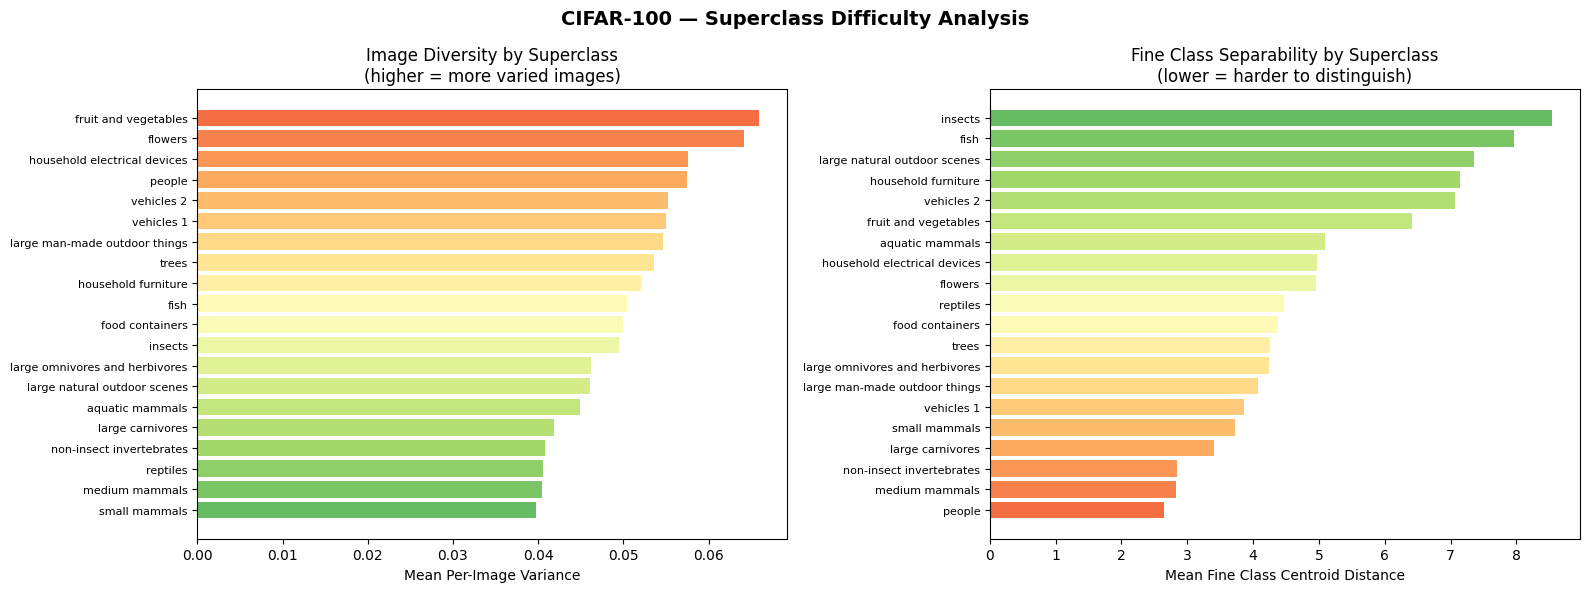


Hardest superclasses (lowest fine class separability):
  people: 2.6480
  medium_mammals: 2.8286
  non-insect_invertebrates: 2.8391
  large_carnivores: 3.4071
  small_mammals: 3.7233

Easiest superclasses (highest fine class separability):
  vehicles_2: 7.0684
  household_furniture: 7.1484
  large_natural_outdoor_scenes: 7.3639
  fish: 7.9685
  insects: 8.5401


In [6]:
# Step 6: [5/8] Superclass Difficulty Analysis

"""
Which superclasses will be hardest for a CNN?
Measure intra-superclass variance (high = diverse = harder)
and inter-class similarity within each superclass
"""

print("=" * 60)
print("[5/8] Superclass Difficulty Analysis")
print("=" * 60)

X_train_norm = X_train.astype(np.float32) / 255.0

# Per-superclass: mean image variance (how diverse are images within the superclass?)
sc_variance = []
sc_intra_similarity = []

for sc_idx in range(20):
    mask = y_train_coarse == sc_idx
    sc_images = X_train_norm[mask]

    # Mean per-image variance (pixel-level diversity)
    per_img_var = np.var(sc_images.reshape(len(sc_images), -1), axis=1)
    sc_variance.append(per_img_var.mean())

    # Intra-superclass: average pairwise distance between fine class centroids
    fine_in_sc = np.unique(y_train_fine[mask])
    centroids = []
    for fc in fine_in_sc:
        fc_mask = y_train_fine[mask] == fc
        centroids.append(sc_images[fc_mask].mean(axis=0).ravel())
    centroids = np.array(centroids)

    # Mean pairwise distance between fine class centroids
    if len(centroids) > 1:
        from scipy.spatial.distance import pdist
        dists = pdist(centroids, metric='euclidean')
        sc_intra_similarity.append(dists.mean())
    else:
        sc_intra_similarity.append(0)

# Plot: variance vs intra-class distance
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Superclass image variance (higher = more diverse images)
sorted_var = sorted(zip(COARSE_NAMES, sc_variance), key=lambda x: x[1])
names_v, vals_v = zip(*sorted_var)
colors_v = plt.cm.RdYlGn_r(np.linspace(0.2, 0.8, 20))
axes[0].barh(range(20), vals_v, color=colors_v)
axes[0].set_yticks(range(20))
axes[0].set_yticklabels([n.replace('_', ' ') for n in names_v], fontsize=8)
axes[0].set_xlabel('Mean Per-Image Variance')
axes[0].set_title('Image Diversity by Superclass\n(higher = more varied images)')

# Intra-superclass fine class distance (lower = harder to distinguish)
sorted_sim = sorted(zip(COARSE_NAMES, sc_intra_similarity), key=lambda x: x[1])
names_s, vals_s = zip(*sorted_sim)
colors_s = plt.cm.RdYlGn(np.linspace(0.2, 0.8, 20))
axes[1].barh(range(20), vals_s, color=colors_s)
axes[1].set_yticks(range(20))
axes[1].set_yticklabels([n.replace('_', ' ') for n in names_s], fontsize=8)
axes[1].set_xlabel('Mean Fine Class Centroid Distance')
axes[1].set_title('Fine Class Separability by Superclass\n(lower = harder to distinguish)')

plt.suptitle('CIFAR-100 — Superclass Difficulty Analysis', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig(f'{EDA_DIR}/eda_superclass_difficulty.png', dpi=150, bbox_inches='tight')
plt.show()

# Print hardest and easiest
print("\nHardest superclasses (lowest fine class separability):")
for name, val in sorted_sim[:5]:
    print(f"  {name}: {val:.4f}")

print("\nEasiest superclasses (highest fine class separability):")
for name, val in sorted_sim[-5:]:
    print(f"  {name}: {val:.4f}")

del X_train_norm

[6/8] Fine Class Average Images


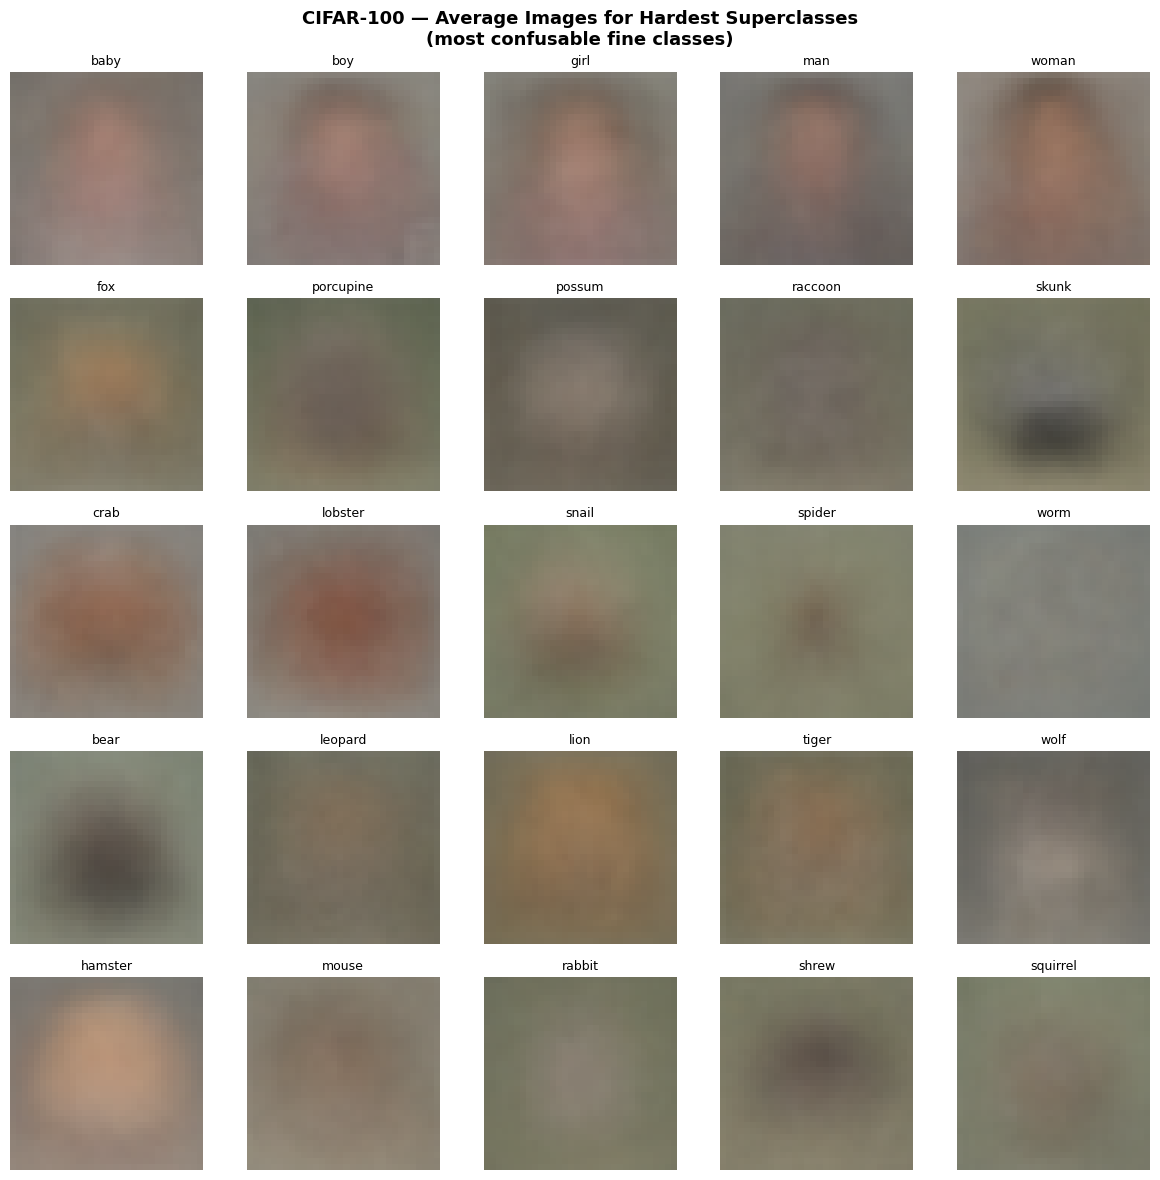

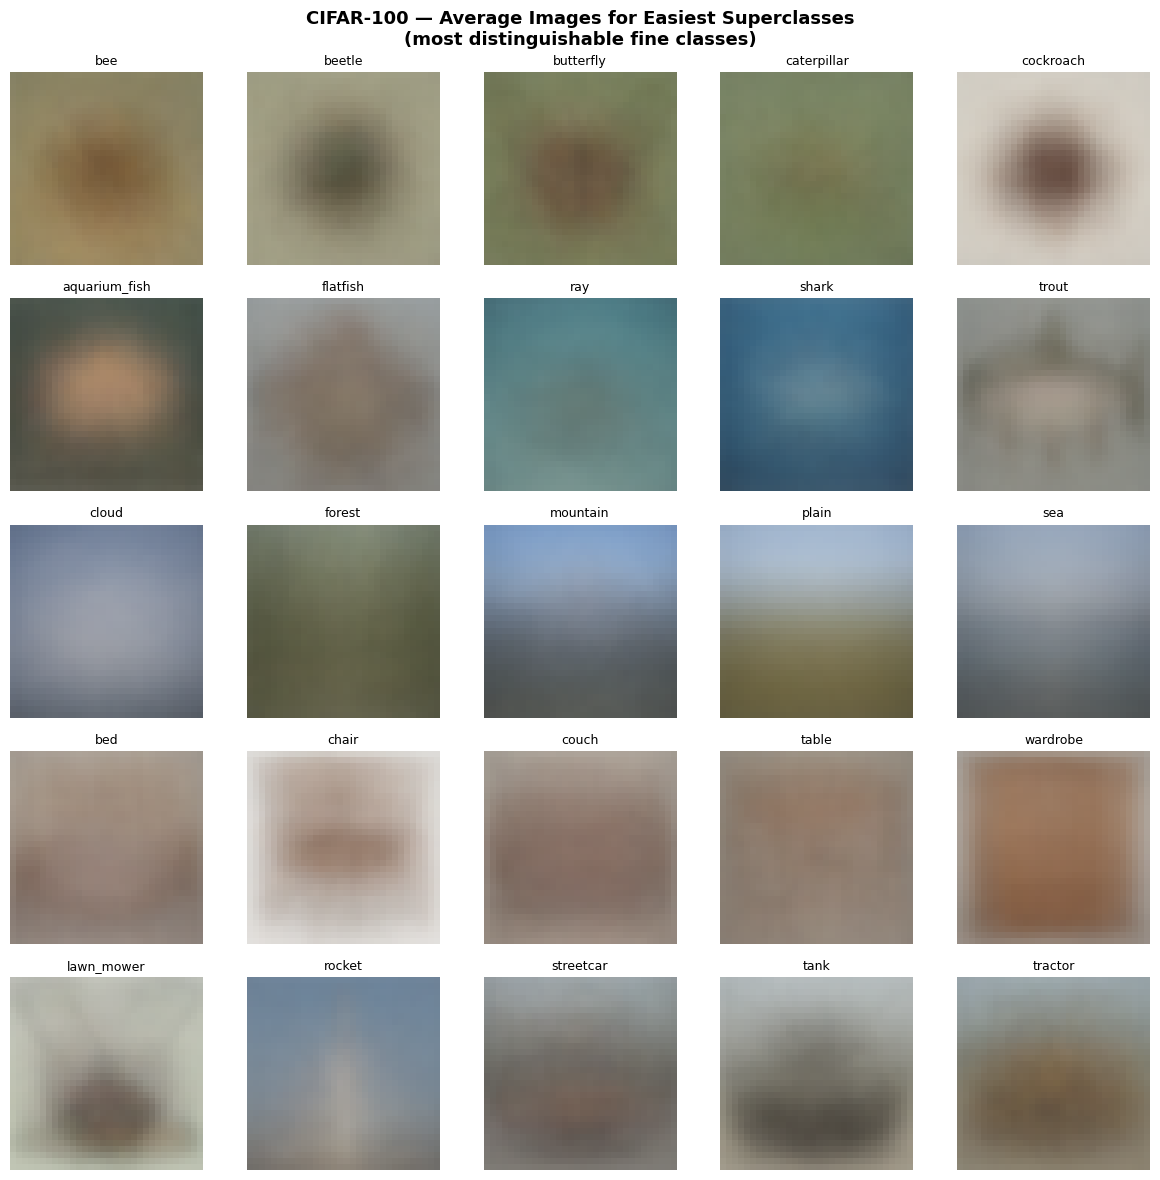


Hardest: People fine classes all blur into similar face shapes
Easiest: Insects have distinct body shapes, fish have different color patterns


In [7]:
# Step 7: [6/8] Fine Class Similarity

"""
Average images per fine class — shows what the CNN "sees" as typical
Identify visually similar classes that will confuse the model
Focus on the hardest superclass: people (baby, boy, girl, man, woman)
"""

print("=" * 60)
print("[6/8] Fine Class Average Images")
print("=" * 60)

# Compute average image per fine class
avg_images = np.zeros((100, 32, 32, 3), dtype=np.float32)
for fc in range(100):
    mask = y_train_fine == fc
    avg_images[fc] = X_train[mask].mean(axis=0)

# Show average images for the 5 hardest superclasses
hardest_scs = ['people', 'medium_mammals', 'non-insect_invertebrates',
               'large_carnivores', 'small_mammals']

fig, axes = plt.subplots(5, 5, figsize=(12, 12))

for row, sc_name in enumerate(hardest_scs):
    fine_classes = SUPERCLASS_MAP[sc_name]
    for col, fc_name in enumerate(fine_classes):
        fc_idx = FINE_NAMES.index(fc_name)
        axes[row, col].imshow(avg_images[fc_idx].astype(np.uint8))
        axes[row, col].axis('off')
        axes[row, col].set_title(fc_name, fontsize=9)
    axes[row, 0].set_ylabel(sc_name.replace('_', '\n'),
                             fontsize=8, rotation=0, labelpad=70, va='center')

plt.suptitle('CIFAR-100 — Average Images for Hardest Superclasses\n(most confusable fine classes)',
             fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig(f'{EDA_DIR}/fine_class_averages_hard.png', dpi=150, bbox_inches='tight')
plt.show()

# Show average images for the 5 easiest superclasses
easiest_scs = ['insects', 'fish', 'large_natural_outdoor_scenes',
               'household_furniture', 'vehicles_2']

fig, axes = plt.subplots(5, 5, figsize=(12, 12))

for row, sc_name in enumerate(easiest_scs):
    fine_classes = SUPERCLASS_MAP[sc_name]
    for col, fc_name in enumerate(fine_classes):
        fc_idx = FINE_NAMES.index(fc_name)
        axes[row, col].imshow(avg_images[fc_idx].astype(np.uint8))
        axes[row, col].axis('off')
        axes[row, col].set_title(fc_name, fontsize=9)
    axes[row, 0].set_ylabel(sc_name.replace('_', '\n'),
                             fontsize=8, rotation=0, labelpad=70, va='center')

plt.suptitle('CIFAR-100 — Average Images for Easiest Superclasses\n(most distinguishable fine classes)',
             fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig(f'{EDA_DIR}/fine_class_averages_easy.png', dpi=150, bbox_inches='tight')
plt.show()

print("\nHardest: People fine classes all blur into similar face shapes")
print("Easiest: Insects have distinct body shapes, fish have different color patterns")

[7/8] Image Complexity by Fine Class


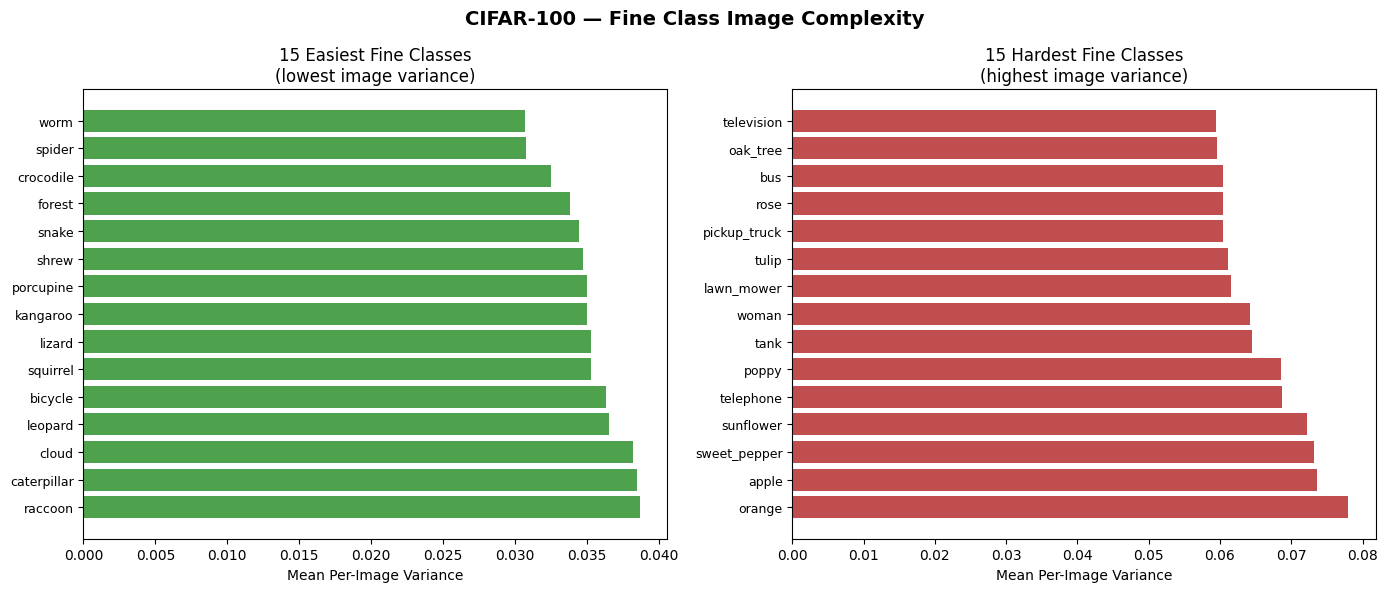


Overall variance range: 0.0307 (worm) to 0.0780 (orange)
Ratio: 2.5x


In [8]:
# Step 8: [7/8] Image Complexity

"""
Per-class variance — which fine classes are easiest/hardest to classify?
High variance = diverse appearances = harder for CNN
"""

print("=" * 60)
print("[7/8] Image Complexity by Fine Class")
print("=" * 60)

X_train_norm = X_train.astype(np.float32) / 255.0

# Per-fine-class: mean image variance
class_complexity = {}
for fc in range(100):
    mask = y_train_fine == fc
    per_img_var = np.var(X_train_norm[mask].reshape(np.sum(mask), -1), axis=1)
    class_complexity[FINE_NAMES[fc]] = per_img_var.mean()

# Sort by complexity
sorted_complexity = sorted(class_complexity.items(), key=lambda x: x[1])

# Plot top 15 easiest and hardest
fig, axes = plt.subplots(1, 2, figsize=(14, 6))

# 15 easiest (lowest variance)
easy_names, easy_vals = zip(*sorted_complexity[:15])
axes[0].barh(range(15), easy_vals, color='forestgreen', alpha=0.8)
axes[0].set_yticks(range(15))
axes[0].set_yticklabels(easy_names, fontsize=9)
axes[0].set_xlabel('Mean Per-Image Variance')
axes[0].set_title('15 Easiest Fine Classes\n(lowest image variance)')
axes[0].invert_yaxis()

# 15 hardest (highest variance)
hard_names, hard_vals = zip(*sorted_complexity[-15:])
axes[1].barh(range(15), hard_vals, color='firebrick', alpha=0.8)
axes[1].set_yticks(range(15))
axes[1].set_yticklabels(hard_names, fontsize=9)
axes[1].set_xlabel('Mean Per-Image Variance')
axes[1].set_title('15 Hardest Fine Classes\n(highest image variance)')
axes[1].invert_yaxis()

plt.suptitle('CIFAR-100 — Fine Class Image Complexity', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig(f'{EDA_DIR}/eda_image_complexity.png', dpi=150, bbox_inches='tight')
plt.show()

print(f"\nOverall variance range: {sorted_complexity[0][1]:.4f} ({sorted_complexity[0][0]}) "
      f"to {sorted_complexity[-1][1]:.4f} ({sorted_complexity[-1][0]})")
print(f"Ratio: {sorted_complexity[-1][1] / sorted_complexity[0][1]:.1f}x")

del X_train_norm

[8/8] Data Augmentation Preview


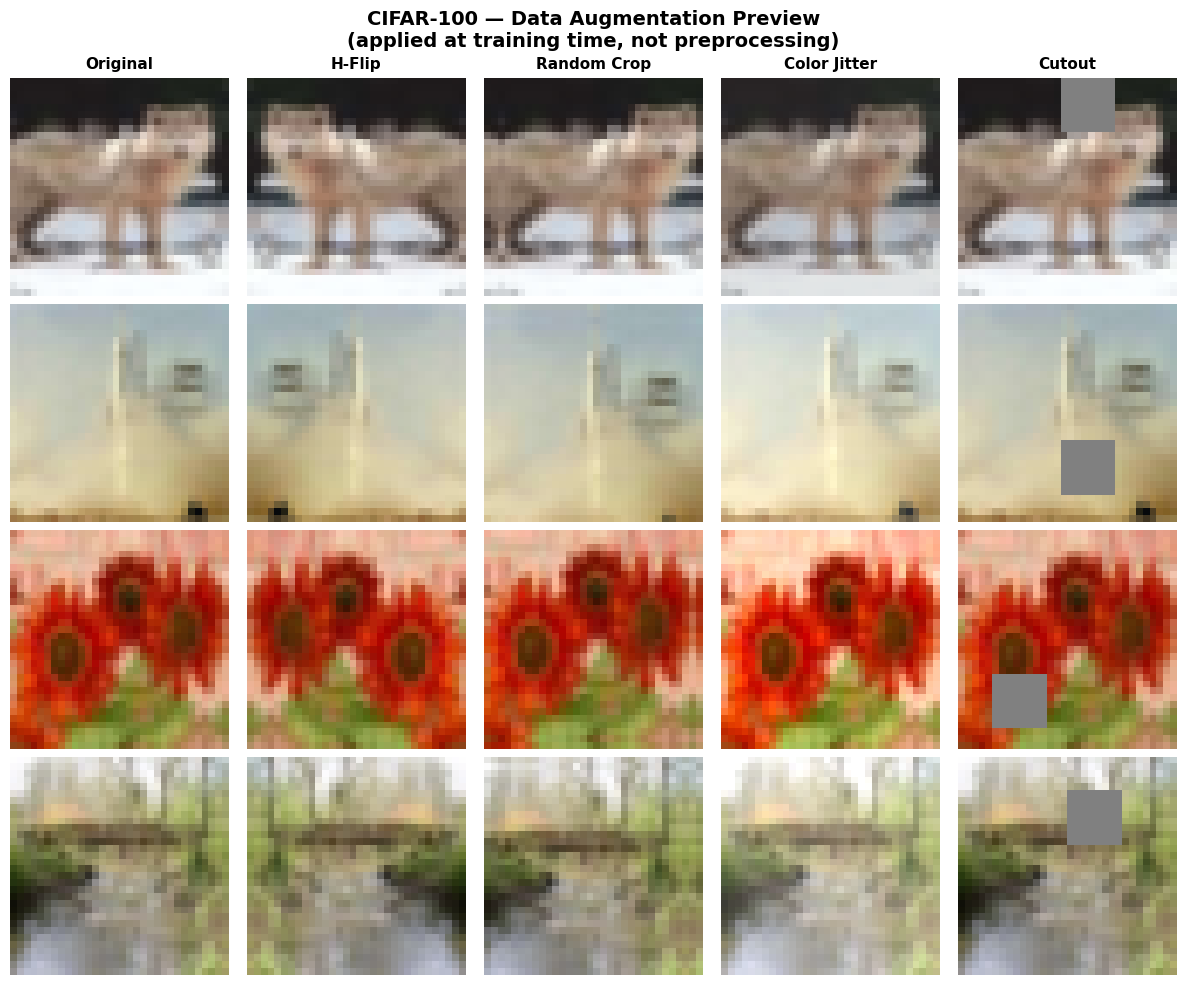


Augmentations planned for CNN training:
  - Horizontal flip (50% probability)
  - Random crop with 4px padding (shifts object position)
  - Color jitter (brightness + contrast variation)
  - Cutout (occlusion regularization, forces learning of partial features)

These will be framework-specific:
  PT: torchvision.transforms
  TF: keras.layers (RandomFlip, RandomRotation, etc.)


In [10]:
# Step 9: [8/8] Data Augmentation Preview

"""
Show what augmented images look like
These augmentations will be applied at training time in the pipelines
Common CNN augmentations: flip, crop, rotation, color jitter
"""

print("=" * 60)
print("[8/8] Data Augmentation Preview")
print("=" * 60)

from PIL import Image

# Pick 4 diverse sample images
rng = np.random.RandomState(113)
sample_indices = [
    rng.choice(np.where(y_train_fine == FINE_NAMES.index('wolf'))[0]),
    rng.choice(np.where(y_train_fine == FINE_NAMES.index('rocket'))[0]),
    rng.choice(np.where(y_train_fine == FINE_NAMES.index('sunflower'))[0]),
    rng.choice(np.where(y_train_fine == FINE_NAMES.index('bridge'))[0]),
]

# Define augmentation functions (numpy-based for EDA preview)
def horizontal_flip(img):
    return img[:, ::-1, :]

def random_crop(img, pad=4):
    padded = np.pad(img, ((pad, pad), (pad, pad), (0, 0)), mode='reflect')
    y = rng.randint(0, 2 * pad)
    x = rng.randint(0, 2 * pad)
    return padded[y:y+32, x:x+32, :]

def color_jitter(img, brightness=0.2, contrast=0.2):
    img_f = img.astype(np.float32)
    # Brightness
    img_f = img_f + rng.uniform(-brightness, brightness) * 255
    # Contrast
    mean = img_f.mean()
    img_f = (img_f - mean) * (1 + rng.uniform(-contrast, contrast)) + mean
    return np.clip(img_f, 0, 255).astype(np.uint8)

def cutout(img, size=8):
    img_c = img.copy()
    y = rng.randint(0, 32 - size)
    x = rng.randint(0, 32 - size)
    img_c[y:y+size, x:x+size, :] = 128  # gray fill
    return img_c

aug_names = ['Original', 'H-Flip', 'Random Crop', 'Color Jitter', 'Cutout']
aug_fns = [lambda x: x, horizontal_flip, random_crop, color_jitter, cutout]

fig, axes = plt.subplots(4, 5, figsize=(12, 10))

for row, idx in enumerate(sample_indices):
    img = X_train[idx]
    for col, (aug_name, aug_fn) in enumerate(zip(aug_names, aug_fns)):
        augmented = aug_fn(img)
        axes[row, col].imshow(augmented)
        axes[row, col].axis('off')
        if row == 0:
            axes[row, col].set_title(aug_name, fontsize=11, fontweight='bold')
    # Label with fine class name
    fc_name = FINE_NAMES[y_train_fine[idx]]
    axes[row, 0].set_ylabel(fc_name, fontsize=10, rotation=0, labelpad=55, va='center')

plt.suptitle('CIFAR-100 — Data Augmentation Preview\n(applied at training time, not preprocessing)',
             fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig(f'{EDA_DIR}/eda_augmentation_preview.png', dpi=150, bbox_inches='tight')
plt.show()

print("\nAugmentations planned for CNN training:")
print("  - Horizontal flip (50% probability)")
print("  - Random crop with 4px padding (shifts object position)")
print("  - Color jitter (brightness + contrast variation)")
print("  - Cutout (occlusion regularization, forces learning of partial features)")
print("\nThese will be framework-specific:")
print("  PT: torchvision.transforms")
print("  TF: keras.layers (RandomFlip, RandomRotation, etc.)")

In [11]:
# Step 10: Summary

print("=" * 60)
print("CIFAR-100 EDA — Summary of Findings")
print("=" * 60)

print("""
DATASET:
  - 60,000 color images (50K train / 10K test), 32x32x3
  - 100 fine classes in 20 superclasses, perfectly balanced (500/class)
  - uint8 [0, 255], minor duplicates (14 train, 2 test, 10 overlap) — negligible

PIXEL STATISTICS:
  - Channel means: R=0.507, G=0.487, B=0.441 (slight red bias)
  - Channel stds:  R=0.267, G=0.256, B=0.276
  - High channel correlation (R-G: 0.86, G-B: 0.89, R-B: 0.71)

DIFFICULTY ANALYSIS:
  - Hardest superclasses: people (2.65), medium_mammals (2.83), non-insect_invertebrates (2.84)
  - Easiest superclasses: insects (8.54), fish (7.97), large_natural_outdoor_scenes (7.36)
  - People fine classes (baby/boy/girl/man/woman) blur into identical face shapes at 32x32
  - Fine class variance range: 2.5x (worm=0.031 to orange=0.078)

PREPROCESSING DECISIONS:
  1. Normalize to [0,1] float32 (X / 255.0) — same as Autoencoders
  2. Save image-shaped only (32,32,3) — no flattening for CNNs
  3. Save both fine (100) and coarse (20) labels for hierarchical evaluation
  4. NO class balancing needed — perfectly balanced
  5. Data augmentation at training time: H-flip, random crop, color jitter, cutout

CNN EXPECTATIONS:
  - 100-class classification is genuinely hard at 32x32 resolution
  - State-of-the-art on CIFAR-100: ~80-85% (with modern architectures + heavy augmentation)
  - Baseline CNN should target 50-60%, architecture sweep should push toward 70%+
  - Superclass-level analysis will reveal where the model fails and why
""")
print("=" * 60)
print("Ready for preprocessing script")

CIFAR-100 EDA — Summary of Findings

DATASET:
  - 60,000 color images (50K train / 10K test), 32x32x3
  - 100 fine classes in 20 superclasses, perfectly balanced (500/class)
  - uint8 [0, 255], minor duplicates (14 train, 2 test, 10 overlap) — negligible

PIXEL STATISTICS:
  - Channel means: R=0.507, G=0.487, B=0.441 (slight red bias)
  - Channel stds:  R=0.267, G=0.256, B=0.276
  - High channel correlation (R-G: 0.86, G-B: 0.89, R-B: 0.71)

DIFFICULTY ANALYSIS:
  - Hardest superclasses: people (2.65), medium_mammals (2.83), non-insect_invertebrates (2.84)
  - Easiest superclasses: insects (8.54), fish (7.97), large_natural_outdoor_scenes (7.36)
  - People fine classes (baby/boy/girl/man/woman) blur into identical face shapes at 32x32
  - Fine class variance range: 2.5x (worm=0.031 to orange=0.078)

PREPROCESSING DECISIONS:
  1. Normalize to [0,1] float32 (X / 255.0) — same as Autoencoders
  2. Save image-shaped only (32,32,3) — no flattening for CNNs
  3. Save both fine (100) and coar